# Nonparametric Collapsed Gibbs sampling

In [6]:
import numpy as np
from collections import Counter

import matplotlib.pyplot as plt

In [2]:
from nonparametric_collapsed_gibbs import CollapsedGibbsDP

%load_ext autoreload
%autoreload 2

In [3]:
FONTSIZE=16
LABELSIZE=0.9*FONTSIZE
LINEWIDTH=2.0
FIGWIDTH=8
ASPECT_RATIO=4/3

plt.rcParams['axes.labelsize'] = FONTSIZE
plt.rcParams['axes.linewidth'] = LINEWIDTH
plt.rcParams['axes.titlesize'] = 1.1*FONTSIZE
plt.rcParams['figure.figsize'] = [FIGWIDTH, FIGWIDTH/ASPECT_RATIO]
plt.rcParams['figure.labelsize'] = FONTSIZE
plt.rcParams['figure.titlesize'] = 1.1*FONTSIZE
plt.rcParams['legend.fancybox'] = False
plt.rcParams['legend.framealpha'] = 1.0
plt.rcParams['legend.fontsize'] = LABELSIZE
plt.rcParams['legend.title_fontsize'] = LABELSIZE
plt.rcParams['patch.linewidth'] = LINEWIDTH
plt.rcParams['lines.linewidth'] = LINEWIDTH
plt.rcParams['xtick.labelsize'] = LABELSIZE
plt.rcParams['ytick.labelsize'] = LABELSIZE
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['figure.autolayout'] = True

plt.rcParams['patch.edgecolor'] = 'black'

In [4]:
DATA_PATH = "../GRBs/GRB_data.txt"
arr = np.loadtxt(DATA_PATH, skiprows=1)
logT90 = arr[:,0]
sigma_logT90 = arr[:,1]

In [ ]:
""" generate data
# generate 2 clusters
x1 = rng_gen.normal(-2.0, 0.5, size=50)
x2 = rng_gen.normal(2.0, 0.7, size=60)
data = np.concatenate([x1, x2])
"""

In [33]:
import pickle

def save_state_pickle(st, filename):
    """Save `st` to filename using pickle."""
    with open(filename, "wb") as f:
        pickle.dump(st, f, protocol=pickle.HIGHEST_PROTOCOL)

def load_state_pickle(filename):
    """Load state (created by save_state_pickle)."""
    with open(filename, "rb") as f:
        st = pickle.load(f)
    return st

In [49]:
%%time
LOAD = 0  # 37min 59s (iter = 1000)
alpha = 0.01

if LOAD == 0:
    # instantiate collapsed Gibbs sampler with weak NIG prior
    rng_gen = np.random.default_rng(1234)
    mid_range = (np.max(logT90) - np.min(logT90))/2.0
    sampler = CollapsedGibbsDP(logT90, alpha=alpha, mu0=mid_range, 
                               kappa0=1e-1, alpha0=2.0, beta0=4.0, 
                               init_clusters=2, rng_gen=rng_gen)
    print("Initial number of clusters:", len(sampler.cluster_ids_))
    sampler.run(1000, verbose=True, collect_param_samples=collect_param_samples, thin=1)
    st = sampler.get_state()
    print("Final num clusters:", len(st['cluster_ids_']))
    print("Counts:", Counter(st['assignment']))

    save_state_pickle(st, f'../chains/assigment_alpha={alpha}.pkl')
else:
    st = load_state_pickle(f'../chains/assigment_alpha={alpha}.pkl')

Initial number of clusters: 2
Iter 100/1000   num_clusters=2   counts={1: 578, 0: 1354}
Iter 200/1000   num_clusters=2   counts={0: 1329, 1: 603}
Iter 300/1000   num_clusters=2   counts={1: 593, 0: 1339}
Iter 400/1000   num_clusters=2   counts={0: 1292, 1: 640}
Iter 500/1000   num_clusters=2   counts={0: 1312, 1: 620}
Iter 600/1000   num_clusters=2   counts={0: 1271, 1: 661}
Iter 700/1000   num_clusters=2   counts={0: 1319, 1: 613}
Iter 800/1000   num_clusters=2   counts={0: 1298, 1: 634}
Iter 900/1000   num_clusters=2   counts={0: 1281, 1: 651}
Iter 1000/1000   num_clusters=2   counts={0: 1329, 1: 603}
Final num clusters: 2
Counts: Counter({0: 1329, 1: 603})
CPU times: user 30min 17s, sys: 42.1 s, total: 30min 59s
Wall time: 29min 56s


N_Iter = 1000, alpha=0.1:

    Initial number of clusters: 2
    Iter 100/1000   num_clusters=2   counts={1: 578, 0: 1354}
    Iter 200/1000   num_clusters=2   counts={0: 1329, 1: 603}
    Iter 300/1000   num_clusters=2   counts={1: 593, 0: 1339}
    Iter 400/1000   num_clusters=2   counts={0: 1292, 1: 640}
    Iter 500/1000   num_clusters=2   counts={0: 1312, 1: 620}
    Iter 600/1000   num_clusters=3   counts={2: 552, 0: 982, 1: 398}
    Iter 700/1000   num_clusters=3   counts={1: 469, 0: 1042, 2: 421}
    Iter 800/1000   num_clusters=3   counts={2: 570, 0: 934, 1: 428}
    Iter 900/1000   num_clusters=3   counts={0: 1142, 2: 346, 1: 444}
    Iter 1000/1000   num_clusters=3   counts={2: 533, 0: 969, 1: 430}
    Final num clusters: 3
    Counts: Counter({0: 969, 2: 533, 1: 430})
    Mean Cluster 0  = 3.770     Sigma Cluster 0 = 0.905
    Mean Cluster 1  = -0.819    Sigma Cluster 1 = 1.091  
    Mean Cluster 2  = 2.349     Sigma Cluster 2 = 1.230

N_Iter = 1000, alpha=0.01:

    Initial number of clusters: 2
    Iter 100/1000   num_clusters=2   counts={1: 578, 0: 1354}
    Iter 200/1000   num_clusters=2   counts={0: 1329, 1: 603}
    Iter 300/1000   num_clusters=2   counts={1: 593, 0: 1339}
    Iter 400/1000   num_clusters=2   counts={0: 1292, 1: 640}
    Iter 500/1000   num_clusters=2   counts={0: 1312, 1: 620}
    Iter 600/1000   num_clusters=2   counts={0: 1271, 1: 661}
    Iter 700/1000   num_clusters=2   counts={0: 1319, 1: 613}
    Iter 800/1000   num_clusters=2   counts={0: 1298, 1: 634}
    Iter 900/1000   num_clusters=2   counts={0: 1281, 1: 651}
    Iter 1000/1000   num_clusters=2   counts={0: 1329, 1: 603}
    Final num clusters: 2
    Mean Cluster 0  = 3.538 	Sigma Cluster 0 = 0.996
    Mean Cluster 1  = -0.246 	Sigma Cluster 1 = 1.369

In [50]:
for i in range(len(st['cluster_ids_'])):
    print(f"Mean Cluster {i}  = {st['suffstats'][i].mean:.3f} \tSigma Cluster {i} = {np.sqrt(st['suffstats'][i].S/(st['suffstats'][i].N+1)):.3f}")

Mean Cluster 0  = 3.538 	Sigma Cluster 0 = 0.996
Mean Cluster 1  = -0.246 	Sigma Cluster 1 = 1.369


In [21]:
from matplotlib.lines import Line2D

def plot_clustered_data(data, assignment, figsize=(7,5), bins=30, alpha=0.6, s=30, title=None):
    data = np.asarray(data)
    assignment = np.asarray(assignment)
    if data.ndim == 1:
        X = data.reshape(-1)
        D = 1
    elif data.ndim == 2 and data.shape[1] == 1:
        X = data.reshape(-1)
        D = 1
    elif data.ndim == 2 and data.shape[1] == 2:
        X = data
        D = 2
    else:
        raise ValueError("data must be 1D (n,) or 2D with shape (n,2) or (n,1). Got shape %s" % (data.shape,))
    
    if X.shape[0] != assignment.shape[0]:
        raise ValueError("data and assignment must have same number of points. Got %d vs %d." % (X.shape[0], assignment.shape[0]))
    
    unique_labels = np.unique(assignment)
    K = unique_labels.size

    fig, ax = plt.subplots(figsize=figsize)
    
    if D == 1:
        for lab in unique_labels:
            vals = X[assignment == lab]
            if vals.size == 0:
                continue
            ax.hist(vals, bins=bins, alpha=alpha, label=f"cluster {int(lab)}", density=False)
        ax.set_xlabel("logT90")
        ax.set_ylabel("count")
        if title is None:
            ax.set_title(f"1D clustered histogram — {K} clusters")
        else:
            ax.set_title(title)
        ax.legend(title="Clusters", bbox_to_anchor=(1.01, 1), loc="upper left")
        plt.tight_layout()
        return fig

    else:
        scatter = ax.scatter(X[:,0], X[:,1], c=assignment, s=s)
        ax.set_xlabel("logT90")
        ax.set_ylabel("HR")
        if title is None:
            ax.set_title(f"2D clustered scatter — {K} clusters")
        else:
            ax.set_title(title)
        # Build legend using Line2D proxies colored according to scatter's colormap mapping
        try:
            cmap = scatter.cmap
            norm = scatter.norm
            handles = []
            labels = []
            for lab in unique_labels:
                color = cmap(norm(lab)) if (cmap is not None and norm is not None) else None
                handles.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=7))
                labels.append(f"cluster {int(lab)}")
            ax.legend(handles, labels, title="Clusters", bbox_to_anchor=(1.01, 1), loc="upper left")
            # add colorbar as well (with discrete ticks)
            try:
                cbar = fig.colorbar(scatter, ax=ax, ticks=unique_labels)
                cbar.set_label("cluster label")
            except Exception:
                pass
        except Exception:
            # fallback: label cluster centers with text
            for lab in unique_labels:
                pts = X[assignment==lab]
                if pts.size == 0:
                    continue
                ax.text(np.mean(pts[:,0]), np.mean(pts[:,1]), str(int(lab)),
                        fontsize=9, ha='center', va='center', bbox=dict(alpha=0.4, boxstyle="round"))
        plt.tight_layout()
        return fig

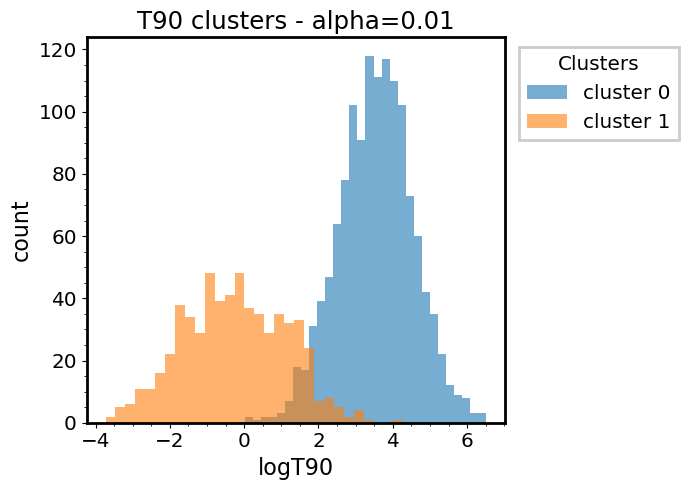

In [52]:
fig1 = plot_clustered_data(logT90, st['assignment'], title=f"T90 clusters - alpha={alpha}")
plt.savefig(f'../figure/gibbs_sampling/T90_cluster_alpha={alpha}.png', dpi=300, bbox_inches='tight')
plt.savefig(f'../figure/gibbs_sampling/T90_cluster_alpha={alpha}.pdf', dpi=300, bbox_inches='tight')
plt.show()